In [1]:
import dipole # use the coordinate transforms from dipole.py
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

save_figs = True

# Dipole Information continued

This document has more information on the dipole coordinate system. Some things are impossible to convey in just words...


First, a primer on the dipole coordinates and some plots of how they look in 2D space:

## Dipole (p,q) coordinates

The magnetic coordinates in Aether are orthogonal to a dipolar magnetic field. The `p` coordinate is the same as L-shell, and `q` paramaterizes the displacement along the magnetic field line. In terms of radius and ***co***latitude, `p` and `q` are calculated as

$$
p = \frac{r}{\sin^2{\theta}}
\tag{1}
$$

$$
q = \frac{\cos{\theta}}{r^2}
\tag{2}
$$

Here is a quick plot of `p` and `q` in 2D space:

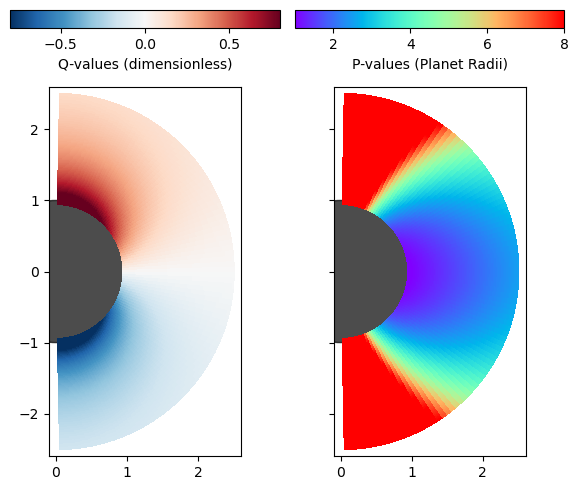

In [2]:
# make r, theta
rs = np.linspace(.95, 2.5, num=100)
thetas = np.deg2rad(np.linspace(-88,  88, num=100))
# turn that into x,y for plotting
xs, ys = dipole.rt2xy(*np.meshgrid(rs, thetas.copy()))
qs, ps = dipole.rt2qp(*np.meshgrid(rs, thetas))

# then the plotting:
fig, axs = plt.subplots(2,2,figsize=(6,5), sharey='row', height_ratios=[.05, 1])

qc = axs[1,0].pcolor(xs, ys, qs, vmin = -0.8, vmax=0.8, cmap='RdBu_r')
fig.colorbar(qc, cax=axs[0,0], orientation='horizontal', label ='Q-values (dimensionless)')

pc = axs[1,1].pcolor(xs, ys, ps, vmin = 1, vmax=8, cmap='rainbow')
fig.colorbar(pc, cax=axs[0,1], orientation='horizontal', label ='P-values (Planet Radii)')

circle0 = plt.Circle((0, 0), 1, color='k', alpha = .7, zorder=-2)
axs[1, 0].add_patch(circle0)
axs[1, 0].set_xlim(-0.1, 2.6)
axs[1, 0].set_ylim(-2.6, 2.6)
axs[1, 0].set_aspect(1);

circle1 = plt.Circle((0, 0), 1, color='k', alpha = .7, zorder=-2)
axs[1, 1].add_patch(circle1)
axs[1, 1].set_xlim(-0.1, 2.6)
axs[1, 1].set_ylim(-2.6, 2.6)
axs[1, 1].set_aspect(1);


plt.tight_layout()

if save_figs:
    fig.savefig('plots/q-p-dipole-global-plot.png')

plt.show();

In Aether, both p and q are stored as native coordinate for the dipole grid, normalized to the planet radius in meters.


## Aether's p,q Values

First, let's get some dipole coordinates:

In [3]:
# Use four blocks:
origins, extent = dipole.generate_sym_quadtree(4)

# call dipole.main, which returns q & p
# These values are a bit unreasonable, but it makes the plots more clear.
qs, ps = dipole.main(alt_minRE=1.01, alt_maxRE=1.3,
                     lat_min=15, lat_max=80,
                     origins=origins, extent=extent, 
                     nLatsPerBlock=14, nAltsPerBlock=18)

# get cartesian & spherical coords:
rs = dipole.qp_solve(qs, ps) #radius
ts = np.rad2deg(dipole.rq2t(rs, qs)) #theta (magLat)

xs, ys = dipole.qp2xy(qs, ps)

# also want the altitude:
alts = dipole.r2alt(rs, 6371) #(in km)

n_y = 14
n_z = 18

### Ghost Cells

The dipole grid has 2 ghost cells in each block (or on each node), similar to the spherical grid.

In the longitudinal direction, these behave as expected.

The latitudinal ghost cells take one of two forms:
- If the node is touching the pole, the final field line is traced from 89$^\circ$ magnetic latitude. This ghost cell will form a supercell.
- Othwerwise, nothing special happens and the final two field lines take the same step in invariant latitude as the rest. This means that boundaries between nodes will overlap. So the invariant latitudes of interior field lines will be identical, but the cell locations will not (since the q-values are different).

The altitudinal ghost cells also take two forms:
- If the node is touching the equator, the last physical cell lies in the same hemisphere as the rest of the cells on that node. The two ghost cells in the altitudinal direction continue to take the same step in q as the previous, thus wrap over the magnetic equator. These ghost cells will line up with the ghost cells from the equator-most node on the opposite hemisphere.
- Othwerwise, the same step in q is taken and there is nothing special.


An image for clarity:

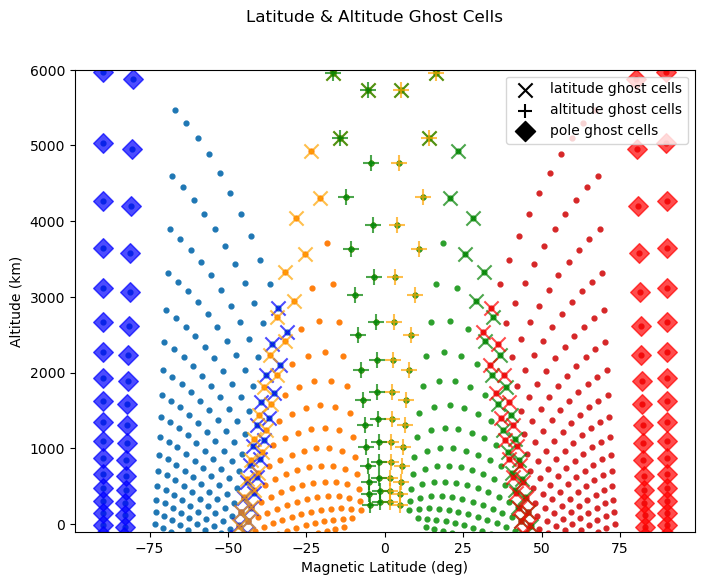

In [4]:
fig, axs = plt.subplots(1, 1, figsize=(8,6))

for n in range(4):
    axs.scatter(ts[n], alts[n], s=12)

# Doing this manually (not looping) since each node is different:
# (interior) latitude ghost cells:
axs.scatter(0,-1000, marker='x', color='k', s=105, label='latitude ghost cells') # only to get label
axs.scatter(ts[0, -2:, :], alts[0, -2:, :], marker='x', alpha = 0.7, s=105, color='blue')
axs.scatter(ts[1,  :2, :], alts[1, :2, :], marker='x', alpha = 0.7, s=105, color='orange')
axs.scatter(ts[2, -2:, :], alts[2, -2:, :], marker='x', alpha = 0.7, s=105, color='green')
axs.scatter(ts[3,  :2, :], alts[3,  :2, :], marker='x', alpha = 0.7, s=105, color='red')

axs.scatter(0,-1000, marker='+', color='k', s=105, label='altitude ghost cells')
axs.scatter(ts[1, :, -2:], alts[1, :, -2:], marker='+', alpha = 0.7, s=125, color='orange')
axs.scatter(ts[2, :, -2:], alts[2, :, -2:], marker='+', alpha = 0.7, s=125, color='green')

axs.scatter(0,-1000, marker='D', color='k', s=105, label='pole ghost cells')
axs.scatter(ts[0, :2, :], alts[0, :2, :], marker='D', alpha = 0.7, s=100, color='blue')
axs.scatter(ts[3, -2:, :], alts[3, -2:, :], marker='D', alpha = 0.7, s=100, color='red')

axs.legend()

axs.set_ylim(-100, 6000)

fig.suptitle("Latitude & Altitude Ghost Cells")
axs.set_xlabel("Magnetic Latitude (deg)")
axs.set_ylabel("Altitude (km)")

if save_figs:
    fig.savefig("plots/ghost-cells-dipole.png")

plt.show();

(The equator-most ghost cells are not shown)


### Order of points

The order of points in the dipole grid is the same as the spherical grid. Most simply, the field lines are arranged in the order of increasing invariant latitude & from lowest to highest altitude.

Where this gets complicated is that the actual values are not necessarily increasing. For example, the altitude of the ghost cells at the ends of field lines touching the equator is not increasing anymore, since the field lines begin curving back towards the center of the planet. Further, since q=0 at the equator the k-coordinate of all points in the southern hemisphere (grid cells with negative values of magnetic latitude) will have negative k-coordinates. 

To help illustrate this, here is a plot where the color of each point is its index along the j or k axis:

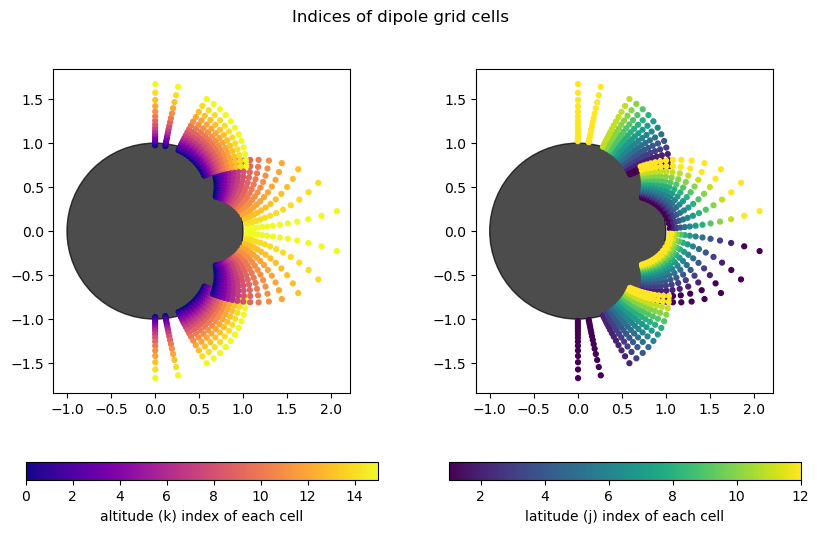

In [5]:
fig, axs = plt.subplots(1,2, figsize=(10,6))

# The weird indexing and adding/subtracting just makes the plot look better
# Ignore some ghost cells, make colorbar clip extrema, etc.

for i in range(4):
    for j in range(n_y):
        ax0 = axs[0].scatter(xs[i, j, :-2], ys[i, j, :-2], s=12, 
                             c=range(n_z-2), vmin=0, vmax=n_z-3,
                             cmap='plasma') # distinct colormap

    for j in range(2, n_z-2):
        ax1 = axs[1].scatter(xs[i, :, j], ys[i, :, j], s=12, 
                             c=range(n_y), vmin=1, vmax=n_y-2, 
                             zorder=4-i) # reverse order points are drawn in

circle0 = plt.Circle((0, 0), 1, color='k', alpha = .7, zorder=0)
circle1 = plt.Circle((0, 0), 1, color='k', alpha = .7, zorder=0)
axs[0].add_patch(circle0)
axs[1].add_patch(circle1)
axs[0].set_aspect(1);
axs[1].set_aspect(1);
fig.colorbar(ax0, ax=axs[0], orientation='horizontal', label='altitude (k) index of each cell')
fig.colorbar(ax1, ax=axs[1], orientation='horizontal', label='latitude (j) index of each cell')

fig.suptitle("Indices of dipole grid cells")

if save_figs:
    fig.savefig("plots/order-of-cells-dipole.png")
    
plt.show();

Since altitude is negative in the southern hemisphere and the k-coordinate is decreasing in the northern hemisphere, the sign of the d_k distances may not be intuitive. 

If there are any other questions, contact Aaron B and this file can be updated with more plots :)